# 📊 Step 3: Exploratory Data Analysis (EDA)

## What This Notebook Does

Before building any model, we need to **understand the data**. This notebook creates
visualizations that answer:

1. **Who are our patients?** Age, gender, ICU type distributions
2. **How are observations spaced?** delta_t distribution (time between measurements)
3. **What do vital signs look like?** Distributions and time trends
4. **What do lab values look like?** Distributions and time trends
5. **How much data is missing?** Missing rates by time period
6. **What treatment patterns exist?** When and how often are treatments given
7. **Do survivors differ from non-survivors?** Key comparisons

### Important Note on Continuous Time
Since our data preserves original timestamps (not hourly grid), we sometimes
**bin data to integer hours for visualization only**. The underlying data remains continuous.

## 📌 Cell 1: Configuration & Data Loading

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['font.size'] = 11
matplotlib.rcParams['figure.figsize'] = (12, 6)
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# =============================================================
# 🔧 USER CONFIGURATION
# =============================================================
MODEL_DIR = "/Users/hoon/Documents/10_Classes/12_Bayesian Machine Learning with Generative AI Applications/10_Final_Project/03_Model_Ready_Data"
FIG_DIR = f"{MODEL_DIR}/figures"
import os; os.makedirs(FIG_DIR, exist_ok=True)

MAX_HOURS_PLOT = 72   # First hours for visualization 72up to

# Data loading
continuous = pd.read_csv(f"{MODEL_DIR}/sepsis_continuous.csv")
cohort = pd.read_csv(f"{MODEL_DIR}/cohort.csv")
cohort['intime'] = pd.to_datetime(cohort['intime'])
cohort['outtime'] = pd.to_datetime(cohort['outtime'])

print(f"Continuous data: {len(continuous):,}rows")
print(f"Cohort: {len(cohort):,} stays")
print(f"Mortality: {cohort['mortality'].mean():.1%}")

Continuous data: 284,673rows
Cohort: 1,502 stays
Mortality: 17.2%


## 📌 Cell 2: Demographics (Figure 1)

Four-panel figure showing cohort characteristics:
- **(a) Age distribution**: Should be roughly uniform between 18-65 (our filter)
- **(b) Gender distribution**: Typically ~55-60% male in ICU populations
- **(c) ICU length of stay**: Distribution within our 12h-10d window
- **(d) Observations per patient**: How many data points each patient has

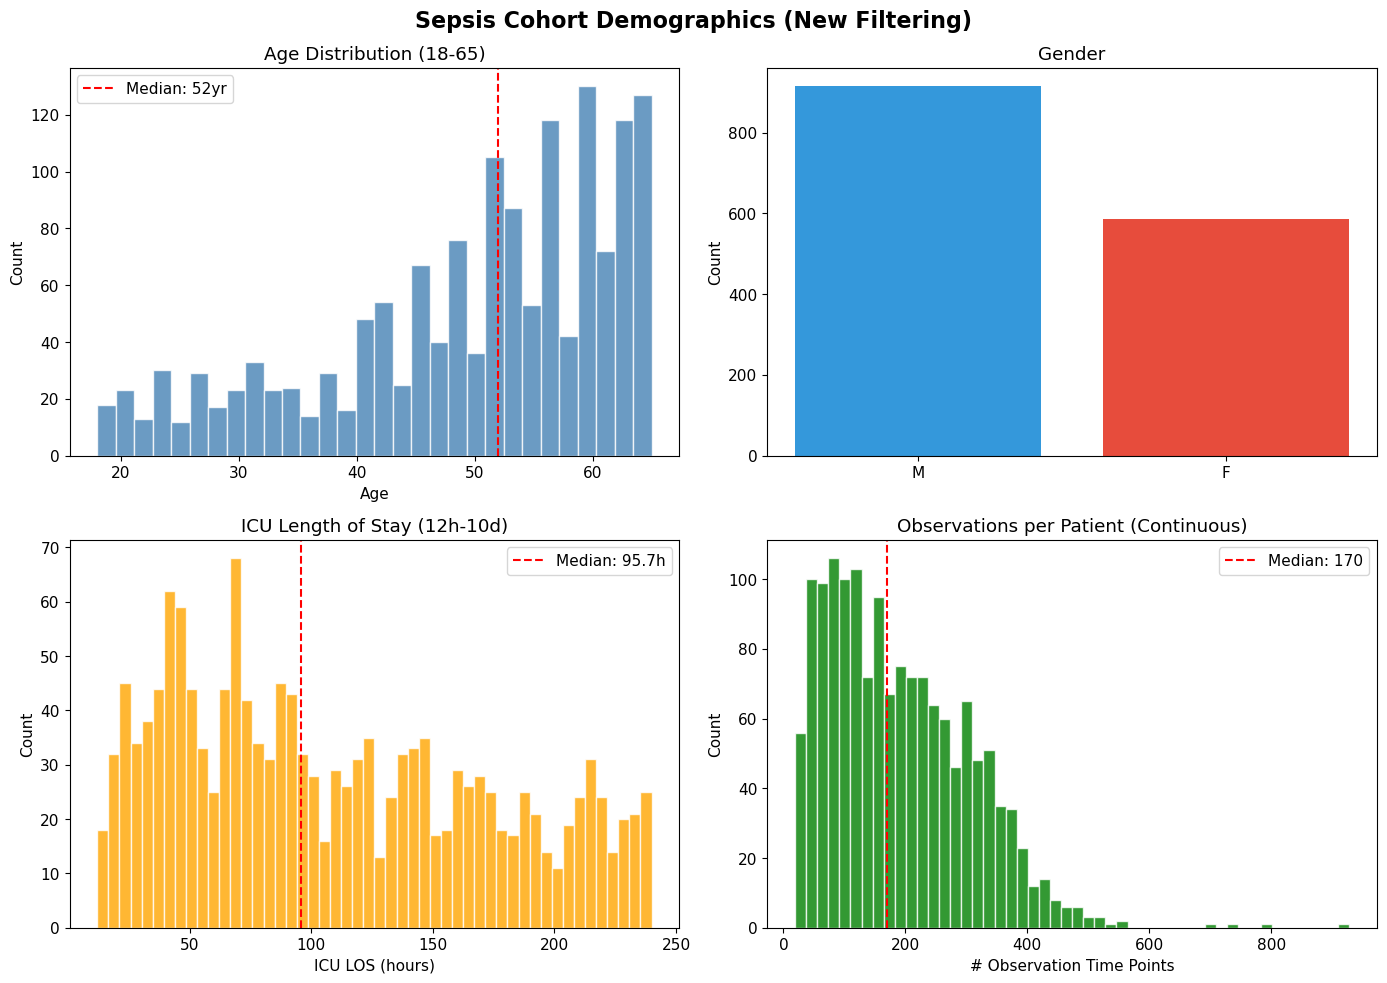

In [2]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Sepsis Cohort Demographics (New Filtering)', fontsize=16, fontweight='bold')

# 1a: Age distribution (18-65)
axes[0,0].hist(cohort['anchor_age'], bins=30, color='steelblue', edgecolor='white', alpha=0.8)
axes[0,0].axvline(cohort['anchor_age'].median(), color='red', ls='--',
                   label=f"Median: {cohort['anchor_age'].median():.0f}yr")
axes[0,0].set_xlabel('Age'); axes[0,0].set_ylabel('Count')
axes[0,0].set_title('Age Distribution (18-65)'); axes[0,0].legend()

# 1b: Gender
gender_counts = cohort['gender'].value_counts()
axes[0,1].bar(gender_counts.index, gender_counts.values, color=['#3498DB', '#E74C3C'])
axes[0,1].set_title('Gender'); axes[0,1].set_ylabel('Count')

# 1c: ICU LOS distribution
axes[1,0].hist(cohort['icu_los_hours'], bins=50, color='orange', edgecolor='white', alpha=0.8)
axes[1,0].axvline(cohort['icu_los_hours'].median(), color='red', ls='--',
                   label=f"Median: {cohort['icu_los_hours'].median():.1f}h")
axes[1,0].set_xlabel('ICU LOS (hours)'); axes[1,0].set_ylabel('Count')
axes[1,0].set_title('ICU Length of Stay (12h-10d)'); axes[1,0].legend()

# 1d: Obs count distribution (per patient)
obs_per_patient = continuous.groupby('stay_id').size()
axes[1,1].hist(obs_per_patient, bins=50, color='green', edgecolor='white', alpha=0.8)
axes[1,1].axvline(obs_per_patient.median(), color='red', ls='--',
                   label=f"Median: {obs_per_patient.median():.0f}")
axes[1,1].set_xlabel('# Observation Time Points'); axes[1,1].set_ylabel('Count')
axes[1,1].set_title('Observations per Patient (Continuous)'); axes[1,1].legend()

plt.tight_layout()
plt.savefig(f"{FIG_DIR}/fig1_demographics.png", dpi=150, bbox_inches='tight')
plt.show()

## 📌 Cell 3: Observation Time Gaps — delta_t Distribution (Figure 2)

**This is the most important EDA figure for our modeling approach.**

It shows how much time passes between consecutive observations. If most gaps are < 2 hours,
our continuous-time approach captures fine-grained dynamics. If gaps are large and irregular,
the delta_t feature in our HMM becomes critical.

Two views:
- **Left**: Zoomed to 0-6 hours (most common range)
- **Right**: Full range (may show rare very long gaps)

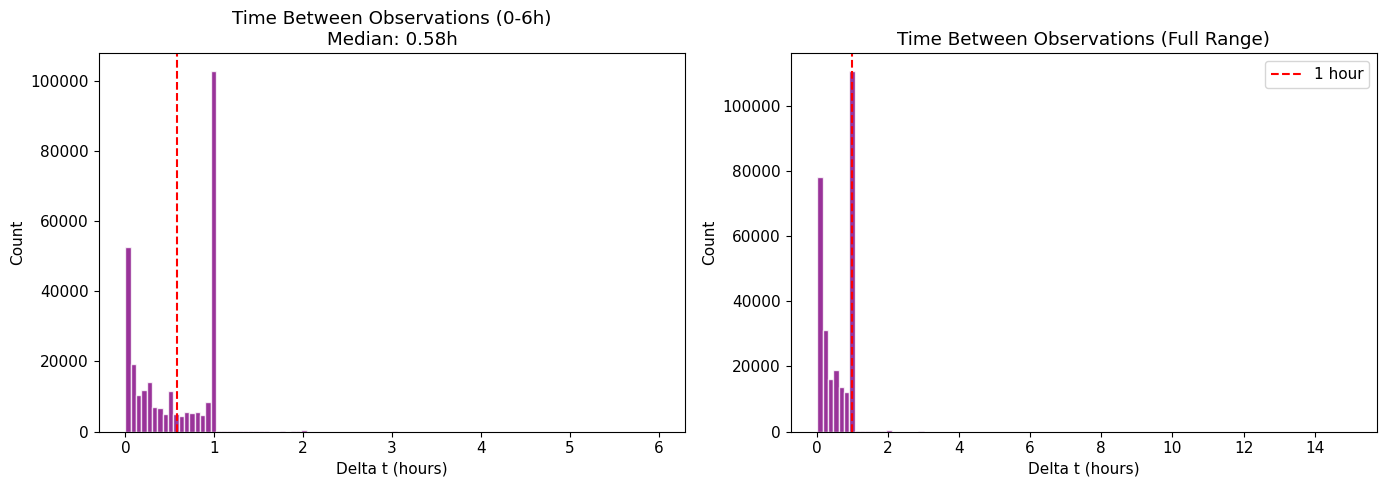

  Delta t stats: mean=0.57h, median=0.58h, min=0.017h, max=15.0h


In [3]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

delta_t = continuous[continuous['delta_t'] > 0]['delta_t']

axes[0].hist(delta_t, bins=100, color='purple', edgecolor='white', alpha=0.8, range=(0, 6))
axes[0].set_xlabel('Delta t (hours)'); axes[0].set_ylabel('Count')
axes[0].set_title(f'Time Between Observations (0-6h)\nMedian: {delta_t.median():.2f}h')
axes[0].axvline(delta_t.median(), color='red', ls='--')

axes[1].hist(delta_t, bins=100, color='purple', edgecolor='white', alpha=0.8)
axes[1].set_xlabel('Delta t (hours)'); axes[1].set_ylabel('Count')
axes[1].set_title('Time Between Observations (Full Range)')
axes[1].axvline(1.0, color='red', ls='--', label='1 hour')
axes[1].legend()

plt.tight_layout()
plt.savefig(f"{FIG_DIR}/fig2_delta_t.png", dpi=150, bbox_inches='tight')
plt.show()
print(f"  Delta t stats: mean={delta_t.mean():.2f}h, median={delta_t.median():.2f}h, "
      f"min={delta_t.min():.3f}h, max={delta_t.max():.1f}h")

## 📌 Cell 4: Vital Sign Distributions (Figure 3)

Box plots for each vital sign across all observations.
Look for: physiological plausibility, outliers that survived cleaning, skewness.

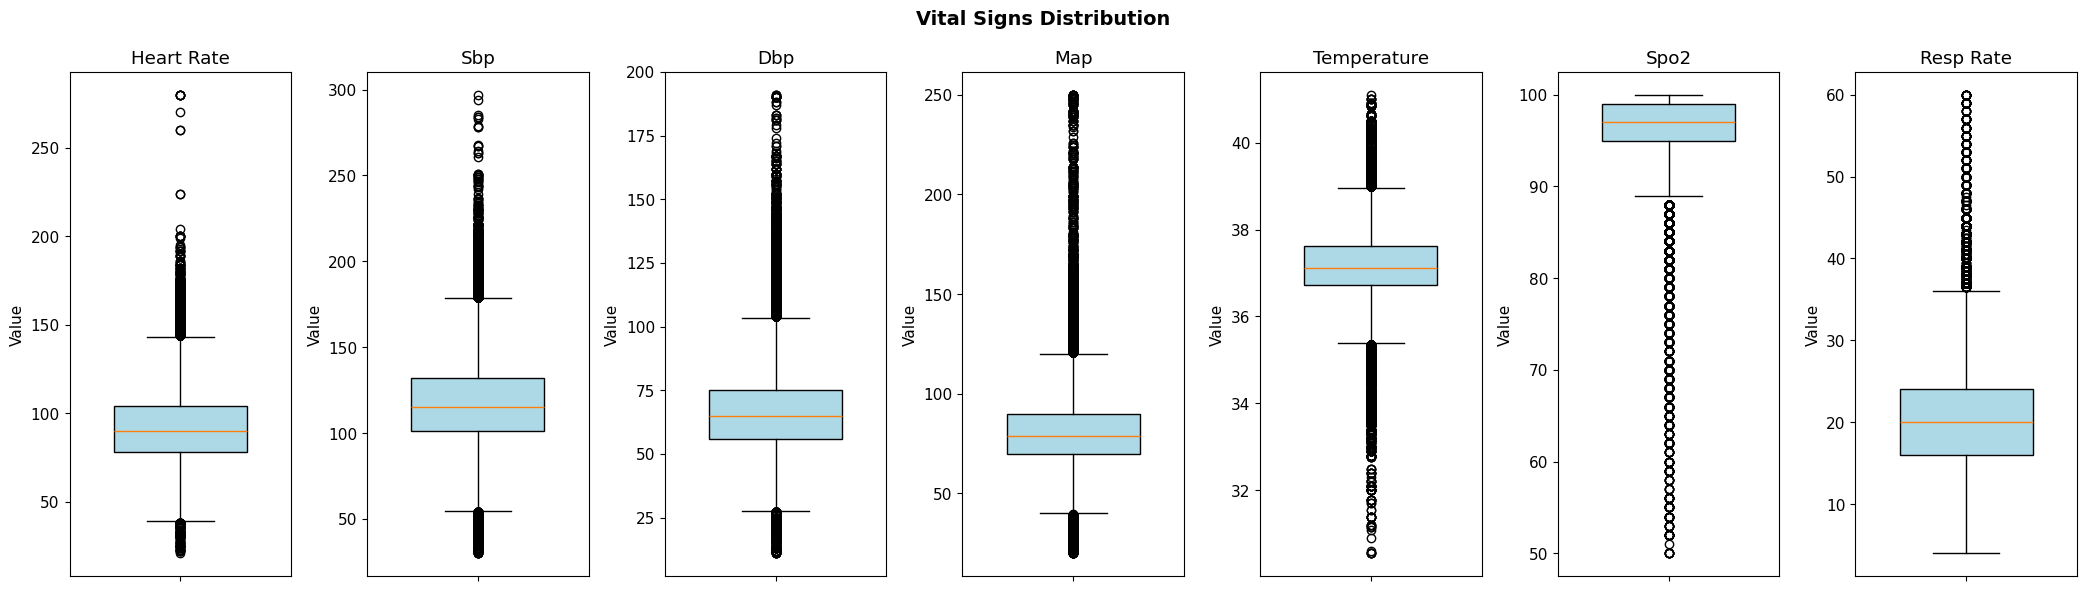

In [4]:
vital_cols = [c for c in ['heart_rate', 'sbp', 'dbp', 'map', 'temperature',
                           'spo2', 'resp_rate'] if c in continuous.columns]

fig, axes = plt.subplots(1, len(vital_cols), figsize=(3*len(vital_cols), 6))
if len(vital_cols) == 1: axes = [axes]

for i, col in enumerate(vital_cols):
    data = continuous[col].dropna()
    axes[i].boxplot(data, vert=True, widths=0.6,
                    patch_artist=True, boxprops=dict(facecolor='lightblue'))
    axes[i].set_title(col.replace('_', ' ').title())
    axes[i].set_ylabel('Value')
    axes[i].tick_params(labelbottom=False)

plt.suptitle('Vital Signs Distribution', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(f"{FIG_DIR}/fig3_vitals.png", dpi=150, bbox_inches='tight')
plt.show()

## 📌 Cell 5: Lab Value Distributions (Figure 4)

Box plots for each lab test. Labs typically have more extreme outliers than vitals
because they measure biochemical concentrations that can vary over orders of magnitude.

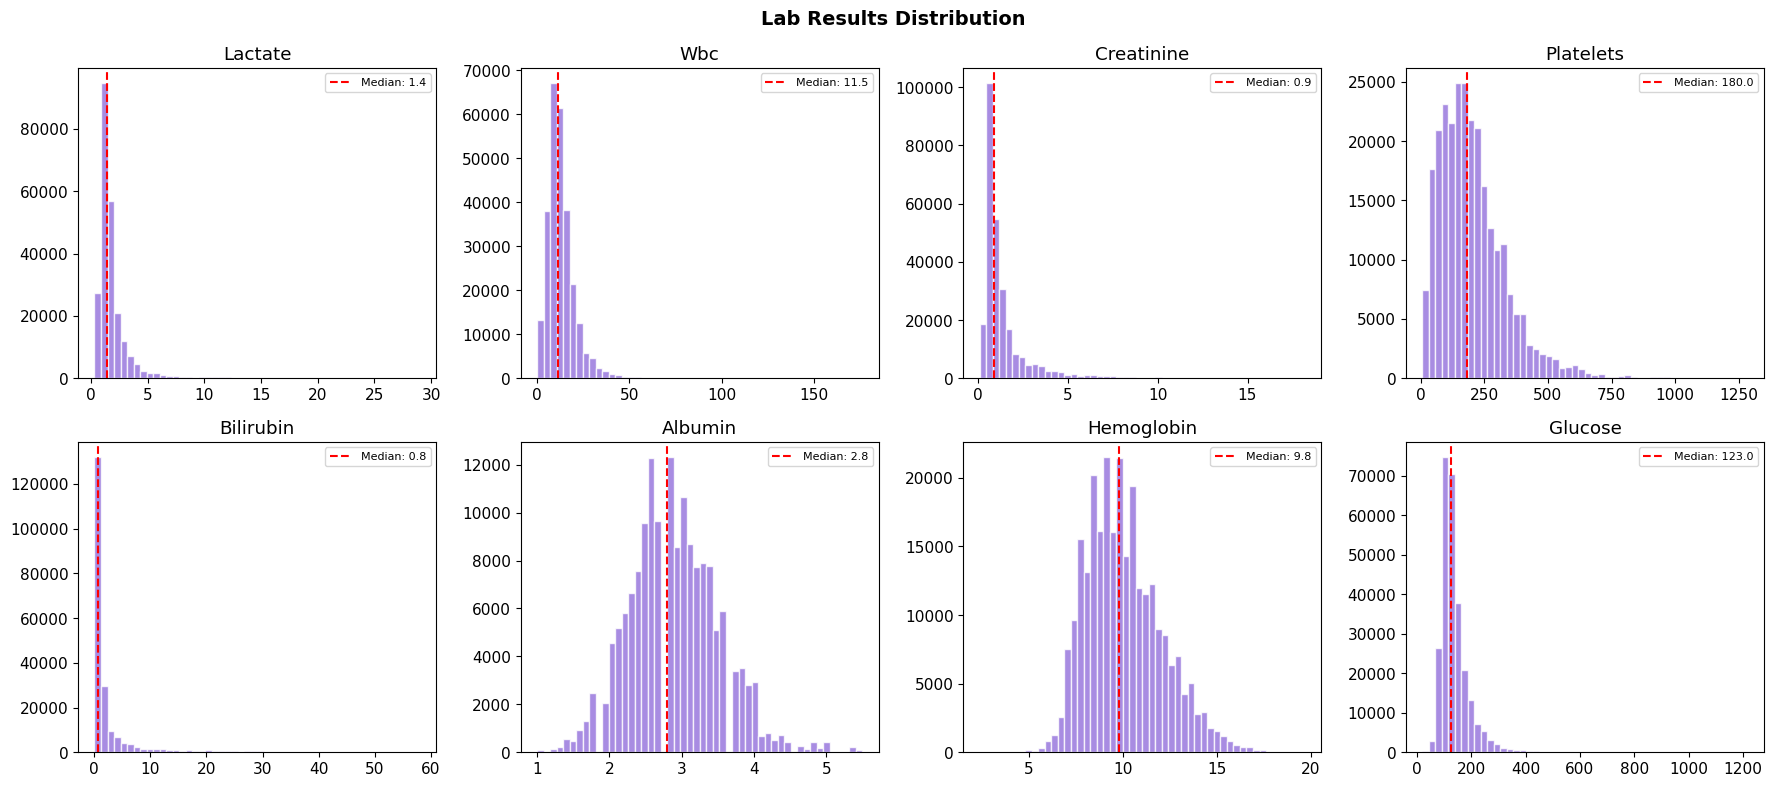

In [5]:
lab_cols = [c for c in ['lactate', 'wbc', 'creatinine', 'platelets', 'bilirubin',
                         'albumin', 'hemoglobin', 'glucose'] if c in continuous.columns]

if lab_cols:
    fig, axes = plt.subplots(2, 4, figsize=(18, 8))
    axes = axes.flatten()
    for i, col in enumerate(lab_cols):
        if i >= len(axes): break
        data = continuous[col].dropna()
        axes[i].hist(data, bins=50, color='mediumpurple', edgecolor='white', alpha=0.8)
        axes[i].axvline(data.median(), color='red', ls='--',
                        label=f'Median: {data.median():.1f}')
        axes[i].set_title(col.replace('_', ' ').title())
        axes[i].legend(fontsize=8)
    for j in range(len(lab_cols), len(axes)):
        axes[j].set_visible(False)
    plt.suptitle('Lab Results Distribution', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.savefig(f"{FIG_DIR}/fig4_labs.png", dpi=150, bbox_inches='tight')
    plt.show()

## 📌 Cell 6: Missing Data Patterns (Figure 5)

**Critical for understanding data quality.**

We bin observations to 1-hour intervals and compute the fraction of missing values
at each hour. This reveals:
- Do missing rates increase over time? (common as monitoring decreases)
- Which features are most/least complete?
- Are there systematic patterns (e.g., labs always missing at certain hours)?

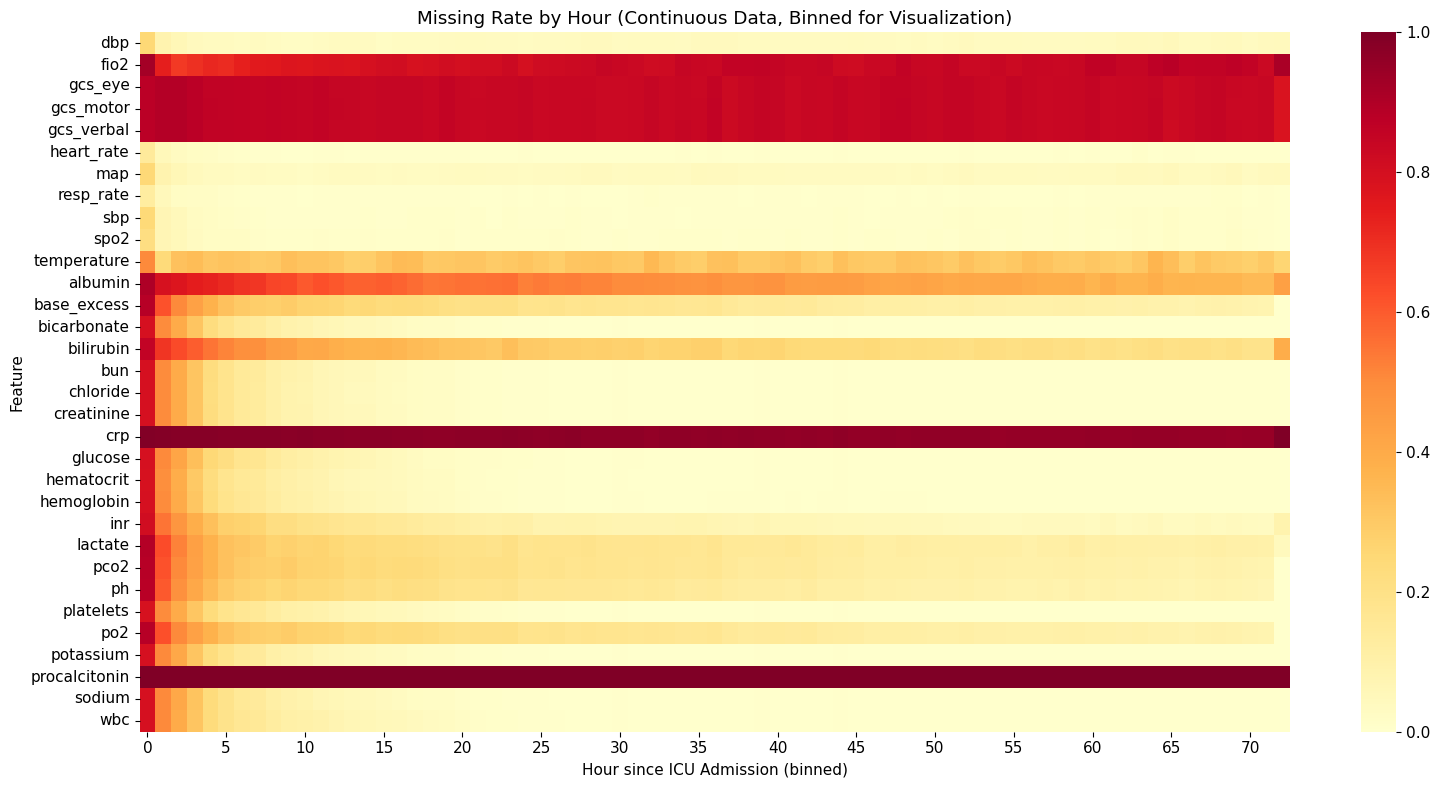

In [6]:
# Bin continuous data to 1-hour intervals to check missing rate (for visualization)
sub = continuous[continuous['hours_in'] <= MAX_HOURS_PLOT].copy()
sub['hour_bin'] = sub['hours_in'].apply(lambda x: int(x))

feature_cols = [c for c in continuous.columns
                if c not in ['stay_id', 'hours_in', 'delta_t', 'subject_id', 'hadm_id',
                             'male', 'anchor_age', 'mortality', 'icu_los_hours',
                             'on_antibiotics', 'on_vasopressors', 'on_iv_fluids']]

missing_by_hour = sub.groupby('hour_bin')[feature_cols].apply(
    lambda x: x.isna().mean()).T

fig, ax = plt.subplots(figsize=(16, 8))
sns.heatmap(missing_by_hour, cmap='YlOrRd', ax=ax, vmin=0, vmax=1,
            xticklabels=5, yticklabels=True)
ax.set_xlabel('Hour since ICU Admission (binned)')
ax.set_ylabel('Feature')
ax.set_title('Missing Rate by Hour (Continuous Data, Binned for Visualization)')
plt.tight_layout()
plt.savefig(f"{FIG_DIR}/fig5_missing.png", dpi=150, bbox_inches='tight')
plt.show()

## 📌 Figure 6: Treatment patterns

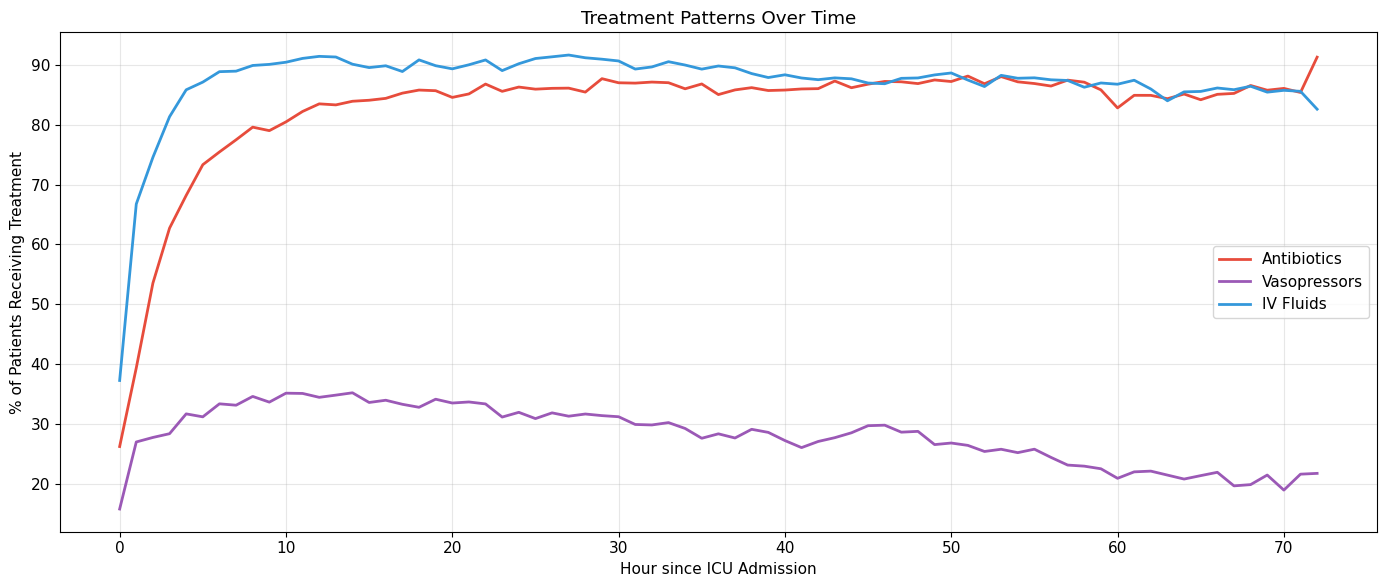

In [7]:
tx_cols = ['on_antibiotics', 'on_vasopressors', 'on_iv_fluids']
tx_labels = ['Antibiotics', 'Vasopressors', 'IV Fluids']
tx_colors = ['#E74C3C', '#9B59B6', '#3498DB']

sub = continuous[continuous['hours_in'] <= MAX_HOURS_PLOT].copy()
sub['hour_bin'] = sub['hours_in'].apply(lambda x: int(x))

fig, ax = plt.subplots(figsize=(14, 6))
for col, label, color in zip(tx_cols, tx_labels, tx_colors):
    if col in sub.columns:
        rate = sub.groupby('hour_bin')[col].mean()
        ax.plot(rate.index, rate.values * 100, label=label, color=color, linewidth=2)

ax.set_xlabel('Hour since ICU Admission')
ax.set_ylabel('% of Patients Receiving Treatment')
ax.set_title('Treatment Patterns Over Time')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(f"{FIG_DIR}/fig6_treatments.png", dpi=150, bbox_inches='tight')
plt.show()

## 📌 Figure 7: Survival vs mortality comparison

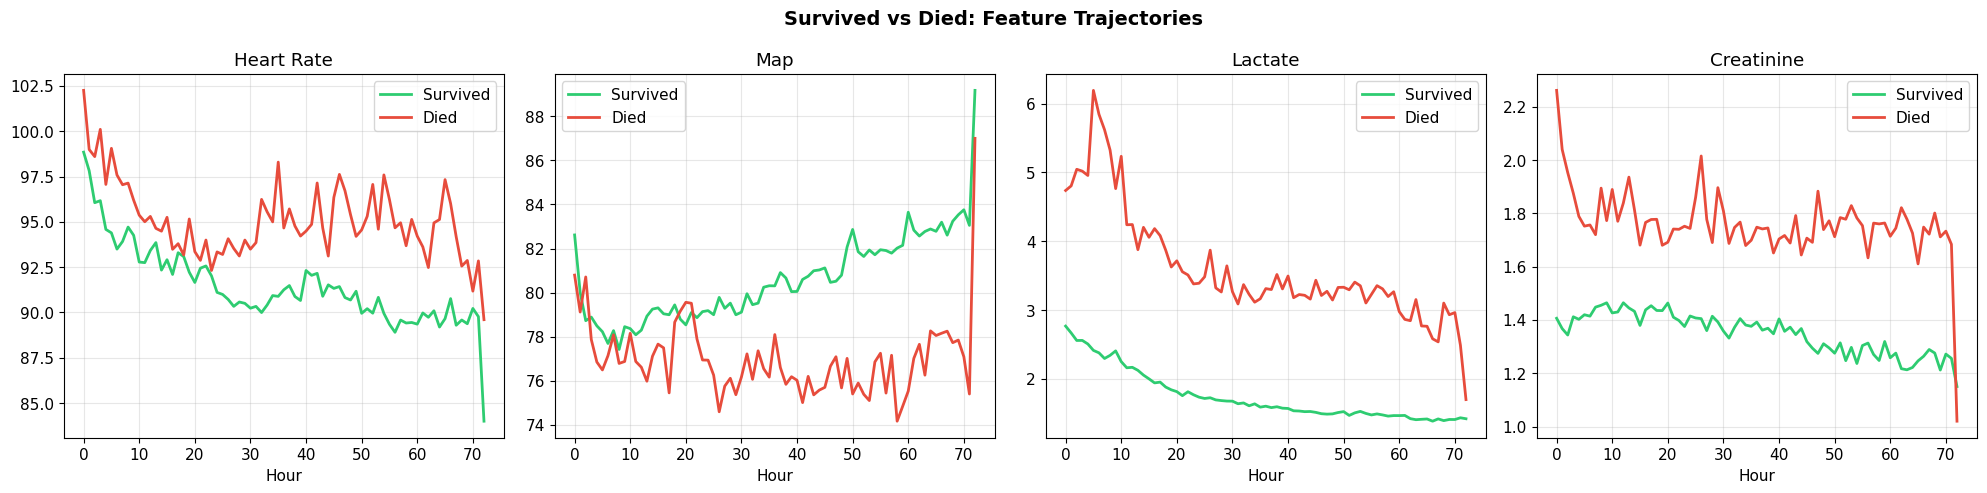

In [8]:
sub = continuous[continuous['hours_in'] <= MAX_HOURS_PLOT].copy()
sub['hour_bin'] = sub['hours_in'].apply(lambda x: int(x))

compare_cols = ['heart_rate', 'map', 'lactate', 'creatinine']
compare_cols = [c for c in compare_cols if c in sub.columns]

if compare_cols:
    fig, axes = plt.subplots(1, len(compare_cols), figsize=(5*len(compare_cols), 5))
    if len(compare_cols) == 1: axes = [axes]
    
    for i, col in enumerate(compare_cols):
        for mort, label, color in [(0, 'Survived', '#2ECC71'), (1, 'Died', '#E74C3C')]:
            group = sub[sub['mortality'] == mort]
            ts = group.groupby('hour_bin')[col].mean()
            axes[i].plot(ts.index, ts.values, label=label, color=color, linewidth=2)
        axes[i].set_title(col.replace('_', ' ').title())
        axes[i].set_xlabel('Hour')
        axes[i].legend()
        axes[i].grid(True, alpha=0.3)
    
    plt.suptitle('Survived vs Died: Feature Trajectories', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.savefig(f"{FIG_DIR}/fig7_survival_comparison.png", dpi=150, bbox_inches='tight')
    plt.show()

## 📌 Data summary

In [9]:
print("=" * 60)
print("📊 EDA SUMMARY (Continuous Time)")
print("=" * 60)
print(f"  Patients:        {cohort['subject_id'].nunique():,}")
print(f"  ICU stays:       {len(cohort):,}")
print(f"  Time points:     {len(continuous):,} (continuous)")
print(f"  Mortality:       {cohort['mortality'].mean():.1%}")
print(f"  Median age:      {cohort['anchor_age'].median():.0f}")
print(f"  Median LOS:      {cohort['icu_los_hours'].median():.1f}h")
delta_t = continuous[continuous['delta_t'] > 0]['delta_t']
print(f"  Median delta_t:  {delta_t.median():.2f}h")
print(f"  Mean delta_t:    {delta_t.mean():.2f}h")

print(f"\n  Missing rates (overall):")
for col in feature_cols:
    if col in continuous.columns:
        miss = continuous[col].isna().mean()
        if miss > 0.01:
            print(f"    {col:20s}: {miss:.1%}")

print("\n🔜 Next: 04_SOFA_Feature_Engineering.ipynb Run")

📊 EDA SUMMARY (Continuous Time)
  Patients:        1,502
  ICU stays:       1,502
  Time points:     284,673 (continuous)
  Mortality:       17.2%
  Median age:      52
  Median LOS:      95.7h
  Median delta_t:  0.58h
  Mean delta_t:    0.57h

  Missing rates (overall):
    dbp                 : 4.1%
    fio2                : 84.5%
    gcs_eye             : 84.5%
    gcs_motor           : 84.6%
    gcs_verbal          : 84.5%
    map                 : 4.1%
    resp_rate           : 1.0%
    sbp                 : 1.6%
    spo2                : 1.7%
    temperature         : 31.4%
    albumin             : 43.2%
    base_excess         : 15.7%
    bicarbonate         : 5.2%
    bilirubin           : 27.6%
    bun                 : 5.2%
    chloride            : 5.2%
    creatinine          : 5.2%
    crp                 : 95.6%
    glucose             : 5.7%
    hematocrit          : 5.3%
    hemoglobin          : 5.5%
    inr                 : 10.6%
    lactate             : 16.9%
    